In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('salaries.csv')

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M


In [19]:
df = pd.read_csv('salaries.csv')

print(df.info())

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 151445 entries, 0 to 151444
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   work_year           151445 non-null  int64
 1   experience_level    151445 non-null  str  
 2   employment_type     151445 non-null  str  
 3   job_title           151445 non-null  str  
 4   salary              151445 non-null  int64
 5   salary_currency     151445 non-null  str  
 6   salary_in_usd       151445 non-null  int64
 7   employee_residence  151445 non-null  str  
 8   remote_ratio        151445 non-null  int64
 9   company_location    151445 non-null  str  
 10  company_size        151445 non-null  str  
dtypes: int64(4), str(7)
memory usage: 12.7 MB
None


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M


In [20]:
df = df.dropna()

In [21]:
df = df.drop_duplicates()
print(f"Liczba wierszy po usunięciu duplikatów: {len(df)}")

Liczba wierszy po usunięciu duplikatów: 71913


C:\Users\ba1na\AppData\Local\Temp\ipykernel_1556\924050925.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_jobs.values, y=top_jobs.index, palette='viridis')


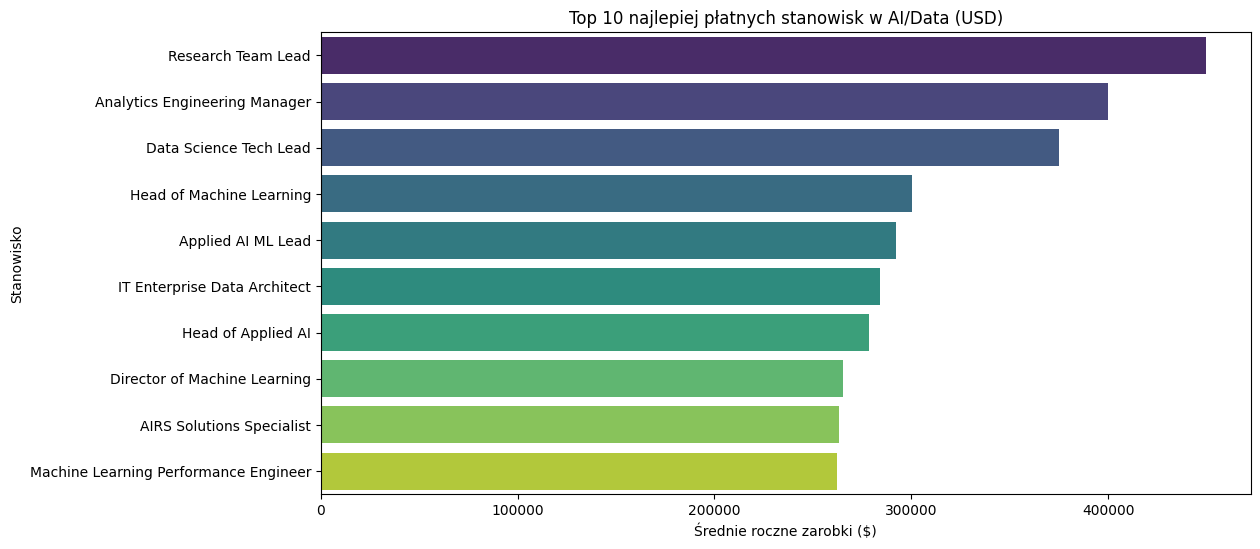

In [22]:
# Grupowanie danych: Obliczamy średnią pensję dla każdego stanowiska
top_jobs = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

# Tworzenie wykresu
plt.figure(figsize=(12, 6))
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette='viridis')
plt.title('Top 10 najlepiej płatnych stanowisk w AI/Data (USD)')
plt.xlabel('Średnie roczne zarobki ($)')
plt.ylabel('Stanowisko')
plt.show()



Summary: The analysis reveals that leadership and specialized engineering roles dominate the highest salary brackets in the AI/Data sector. Research Team Leads and Analytics Engineering Managers earn significantly more than other roles, with average annual salaries exceeding $400,000. This suggests that as the AI field matures, the market places a premium on professionals who can bridge the gap between complex research and scalable engineering management. For an aspiring analyst, this highlights a lucrative long-term career path towards specialized engineering leadership.

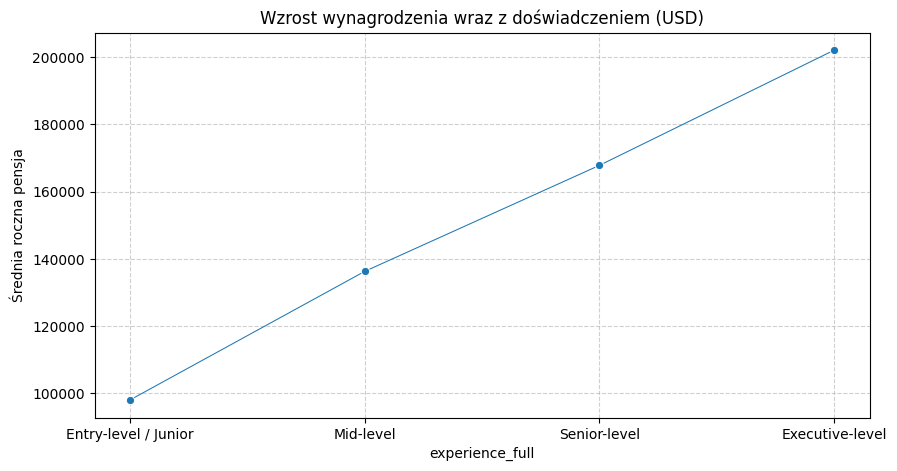

In [23]:
# Mapujemy skróty na czytelne nazwy
mapping = {'EN': 'Entry-level / Junior', 'MI': 'Mid-level', 'SE': 'Senior-level', 'EX': 'Executive-level'}
df['experience_full'] = df['experience_level'].map(mapping)

# Liczymy średnią dla każdego poziomu
exp_salary = df.groupby('experience_full')['salary_in_usd'].mean().sort_values()

# Wykres liniowy lub słupkowy
plt.figure(figsize=(10, 5))
sns.lineplot(x=exp_salary.index, y=exp_salary.values, marker='o', size=15, legend=False)
plt.title('Wzrost wynagrodzenia wraz z doświadczeniem (USD)')
plt.ylabel('Średnia roczna pensja')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()